kaggle datasets download dschettler8845/brats-2021-task1 -f BraTS2021_Training_Data.tar

tar -xf BraTS2021_Training_Data.tar

## Éléments nécéssaires au notebook

### Imports

In [4]:
import numpy as np
import matplotlib.pyplot as plt
import os
join = os.path.join
from tqdm import tqdm
import torch
import torchvision
from torch.utils.data import Dataset, DataLoader
import monai
from segment_anything import SamPredictor, sam_model_registry
from segment_anything.utils.transforms import ResizeLongestSide
# from utils.SurfaceDice import compute_dice_coefficient Ne fonctionne pas 
import skimage
# set seeds
torch.manual_seed(2023)
np.random.seed(2023)

In [5]:
# MOI ajout des imports qui sont partout dans le doc ici : 
import tarfile
import nibabel as nib
import glob
import numpy as np
import matplotlib.pyplot as plt
from ipywidgets import interact
import seaborn as sns
import pickle
import pandas as pd # Ajouté pour les stats

In [7]:
#If your data is .tar format, you can run this cell to extract it
'''
# import tarfile localisation initiale 
file = tarfile.open('./BraTS2021_Training_Data.tar')
file.extractall('./brain_images')
file.close()
'''

"\n# import tarfile localisation initiale \nfile = tarfile.open('./BraTS2021_Training_Data.tar')\nfile.extractall('./brain_images')\nfile.close()\n"

# Notebook explicatif pour un sujet

In [16]:
# Chemins généraux : 
data_path = '../source_data'
sujet = 'BraTS2021_00000' 
model_paths = '../code/models'
slice_index = 60 # La couche ou la segmentation sera faite 

In [7]:
# Ouverture des scans originaux : le scan et la segmentation réelle (ground truth)
# Format : .nii.gz 

# Chemin de fichiers 
scan_path = f'{data_path}/{sujet}/{sujet}_t2.nii.gz'
gt_path = f'{data_path}/{sujet}/{sujet}_seg.nii.gz'

# Load les fichiers 
scan_obj = nib.load(scan_path)
gt_obj = nib.load(gt_path)

# Validation 
type(scan_obj) 

scan_data = scan_obj.get_fdata()
print('Scan data  :', type(scan_data), scan_data.shape)

gt_data = gt_obj.get_fdata()
print('Ground truth', type(gt_data), gt_data.shape)


Scan data  : <class 'numpy.ndarray'> (240, 240, 155)
Ground truth <class 'numpy.ndarray'> (240, 240, 155)


In [ ]:
# Préparation des scans 2d (images scan et gt original = 3d)

# Obtenir les slices (image 2d) pour la bonne couche 
def get_slice_pair(layer, scan_data, gt_data):
    return scan_data[:, :, layer],gt_data[:, :, layer]

# Mettre dans le format nécéssaire pour les modèles 
def sam_imput_format(scan_2d) : 
    if scan_2d.shape[-1]>3 and len(scan_2d.shape)==3:
        scan_2d = scan_2d[:,:,:3]
    if len(scan_2d.shape)==2:
        scan_2d = np.repeat(scan_2d[:,:,None], 3, axis=-1)
    return scan_2d

# Obtenir l'image 2d originale et sa segmentation associée (pour la couche données)
scan_2d_og,gt_2d = get_slice_pair(slice_index, scan_data, gt_data)

# Good format
scan_2d = sam_imput_format(scan_2d_og)

## Visualisation initiale

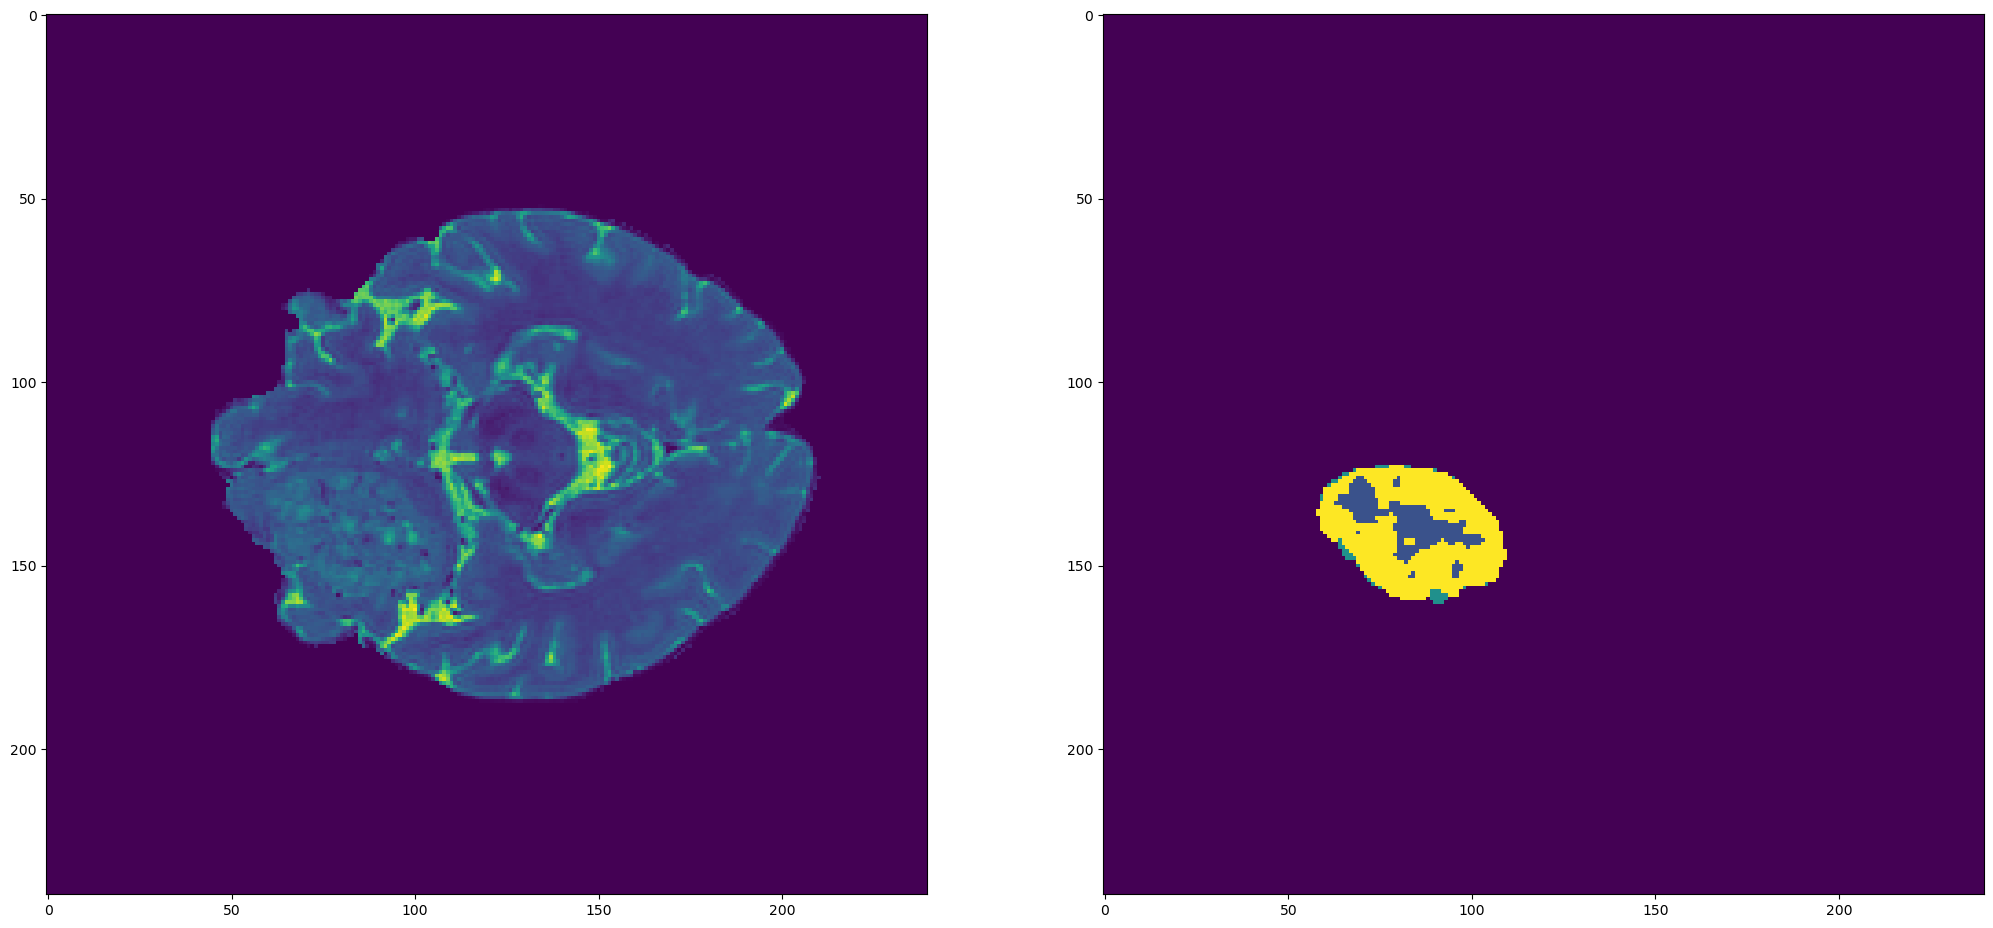

In [10]:
#Visualize the original MRI slice and corresponding mask
_, axs = plt.subplots(1, 2, figsize=(25, 25))
axs[0].imshow(scan_2d_og)
axs[1].imshow(gt_2d)
plt.show() 
plt.close()

## Segmentation par le modèle 1 : SAM 

### Initialisation des modèles

In [17]:
# Préparations pour les modèles 
from pathlib import Path

def initialisation_modeles(modeles_path) : 
    model_type = 'vit_b'
    #sam_model_checkpoint = '../models/sam_vit_b_01ec64.pth'
    #med_sam_model_checkpoint = '../models/sam_model_best.pth' # Not the original but matches the link

    sam_model_checkpoint = Path(modeles_path) / 'sam_vit_b_01ec64.pth'
    med_sam_model_checkpoint = Path(modeles_path) / 'sam_model_best.pth' 

    device = torch.device('cpu')

    sam_model = sam_model_registry[model_type](checkpoint=None)
    sam_model.load_state_dict(torch.load(sam_model_checkpoint, map_location=torch.device('cpu')))
    sam_model.to(device)

    med_sam_model = sam_model_registry[model_type](checkpoint=None)
    med_sam_model.load_state_dict(torch.load(med_sam_model_checkpoint, map_location=torch.device('cpu')))
    med_sam_model.to(device)

    sam_predictor = SamPredictor(sam_model)
    med_sam_predictor = SamPredictor(med_sam_model)

    print('Initialisation modèles terminée')
    return sam_predictor, med_sam_predictor, med_sam_model

# Load des modèles
sam_predictor, med_sam_predictor, med_sam_model = initialisation_modeles(model_paths)

Initialisation modèles terminée


### Préparation des scans 

Ici, on crée un objet qui indique au modèle dans quelle région se trouve l'objet à segmenter 

Ensuite le scan doit être dans le bon format pour le modèle

In [20]:
def get_bbox_from_mask(mask):
    '''Returns a bounding box from a mask'''
    y_indices, x_indices = np.where(mask > 0)
    x_min, x_max = np.min(x_indices), np.max(x_indices)
    y_min, y_max = np.min(y_indices), np.max(y_indices)
    # add perturbation to bounding box coordinates
    H, W = mask.shape
    x_min = max(0, x_min - np.random.randint(0, 20))
    x_max = min(W, x_max + np.random.randint(0, 20))
    y_min = max(0, y_min - np.random.randint(0, 20))
    y_max = min(H, y_max + np.random.randint(0, 20))

    return np.array([x_min, y_min, x_max, y_max])

def preprocess_scan(scan_2d):
    lower_bound, upper_bound = np.percentile(scan_2d, 0.5), np.percentile(scan_2d, 99.5)
    scan_2d_pre = np.clip(scan_2d, lower_bound, upper_bound)
    scan_2d_pre = (scan_2d_pre - np.min(scan_2d_pre))/(np.max(scan_2d_pre)-np.min(scan_2d_pre))*255.0
    scan_2d_pre[scan_2d==0] = 0
    scan_2d_pre = np.uint8(scan_2d_pre)
    return scan_2d_pre

# Boite qui indique au modèle quelle région se trouve l'objet à segmenter 
gt_box = get_bbox_from_mask(gt_2d)

# Preprocess to get in the format needed by models :
scan_2d_pre = preprocess_scan(scan_2d)

# Validation 
print("Shape gt:", gt_2d.shape)
print("Shape scan:", scan_2d_pre.shape)

Shape gt: (240, 240)
Shape scan: (240, 240, 3)


## Segmentation des deux modèles

In [ ]:
def get_sam_seg(scan_2d, bbox_raw, sam_predictor) :
    # predict the segmentation mask using the original SAM model
    sam_predictor.set_image(scan_2d)
    sam_seg, _, _ = sam_predictor.predict(point_coords=None, box=bbox_raw, multimask_output=False)
    #print(sam_seg.shape) 
    print("Segmentation SAM terminée")
    return sam_seg

def get_medsam_seg(scan_2d, bbox_raw, med_sam_model):

    device = 'cpu'

    med_sam_transform = ResizeLongestSide(med_sam_model.image_encoder.img_size)
    resize_img = med_sam_transform.apply_image(scan_2d)
    resize_img_tensor = torch.as_tensor(resize_img.transpose(2, 0, 1)).to(device)
    input_image = med_sam_model.preprocess(resize_img_tensor[None,:,:,:]) # (1, 3, 1024, 1024)
    assert input_image.shape == (1, 3, med_sam_model.image_encoder.img_size, med_sam_model.image_encoder.img_size), 'input image should be resized to 1024*1024'

    with torch.no_grad():
        
        H, W, _ = scan_2d.shape
        # pre-compute the image embedding
        ts_img_embedding = med_sam_model.image_encoder(input_image)
        # convert box to 1024x1024 grid
        bbox = med_sam_transform.apply_boxes(bbox_raw, (H, W))
        #print(f'{bbox_raw=} -> {bbox=}')

        box_torch = torch.as_tensor(bbox, dtype=torch.float, device=device)
        if len(box_torch.shape) == 2:
            box_torch = box_torch[:, None, :] # (B, 4) -> (B, 1, 4)
        
        sparse_embeddings, dense_embeddings = med_sam_model.prompt_encoder(
            points=None,
            boxes=box_torch,
            masks=None,
        )
        medsam_seg_prob, _ = med_sam_model.mask_decoder(
            image_embeddings=ts_img_embedding.to(device), # (B, 256, 64, 64)
            image_pe=med_sam_model.prompt_encoder.get_dense_pe(), # (1, 256, 64, 64)
            sparse_prompt_embeddings=sparse_embeddings, # (B, 2, 256)
            dense_prompt_embeddings=dense_embeddings, # (B, 256, 64, 64)
            multimask_output=False,
            )
        medsam_seg_prob = torch.sigmoid(medsam_seg_prob)
        # convert soft mask to hard mask
        medsam_seg_prob = medsam_seg_prob.cpu().numpy().squeeze()
        medsam_seg = (medsam_seg_prob > 0.5).astype(np.uint8)

        medsam_seg = skimage.transform.resize(medsam_seg,(240,240))
        medsam_seg = skimage.util.img_as_ubyte(medsam_seg)
        #print(medsam_seg.shape)
        #print(medsam_seg)

        print("Segmentation MEDSAM terminée! :)")
        return medsam_seg

# Segmentation de SAM
sam_seg = get_sam_seg(scan_2d_pre, gt_box, sam_predictor)
medsam_seg = get_medsam_seg(scan_2d_pre, gt_box, med_sam_model)

Segmentation SAM terminée
Segmentation MEDSAM terminée! :)


# Métriques et explications 

### Dice score 

In [23]:
sam_dsc = 3
medsam_dsc = 3

### Précision vs Recall

### Métriques de périmetres

# Visualisation finale

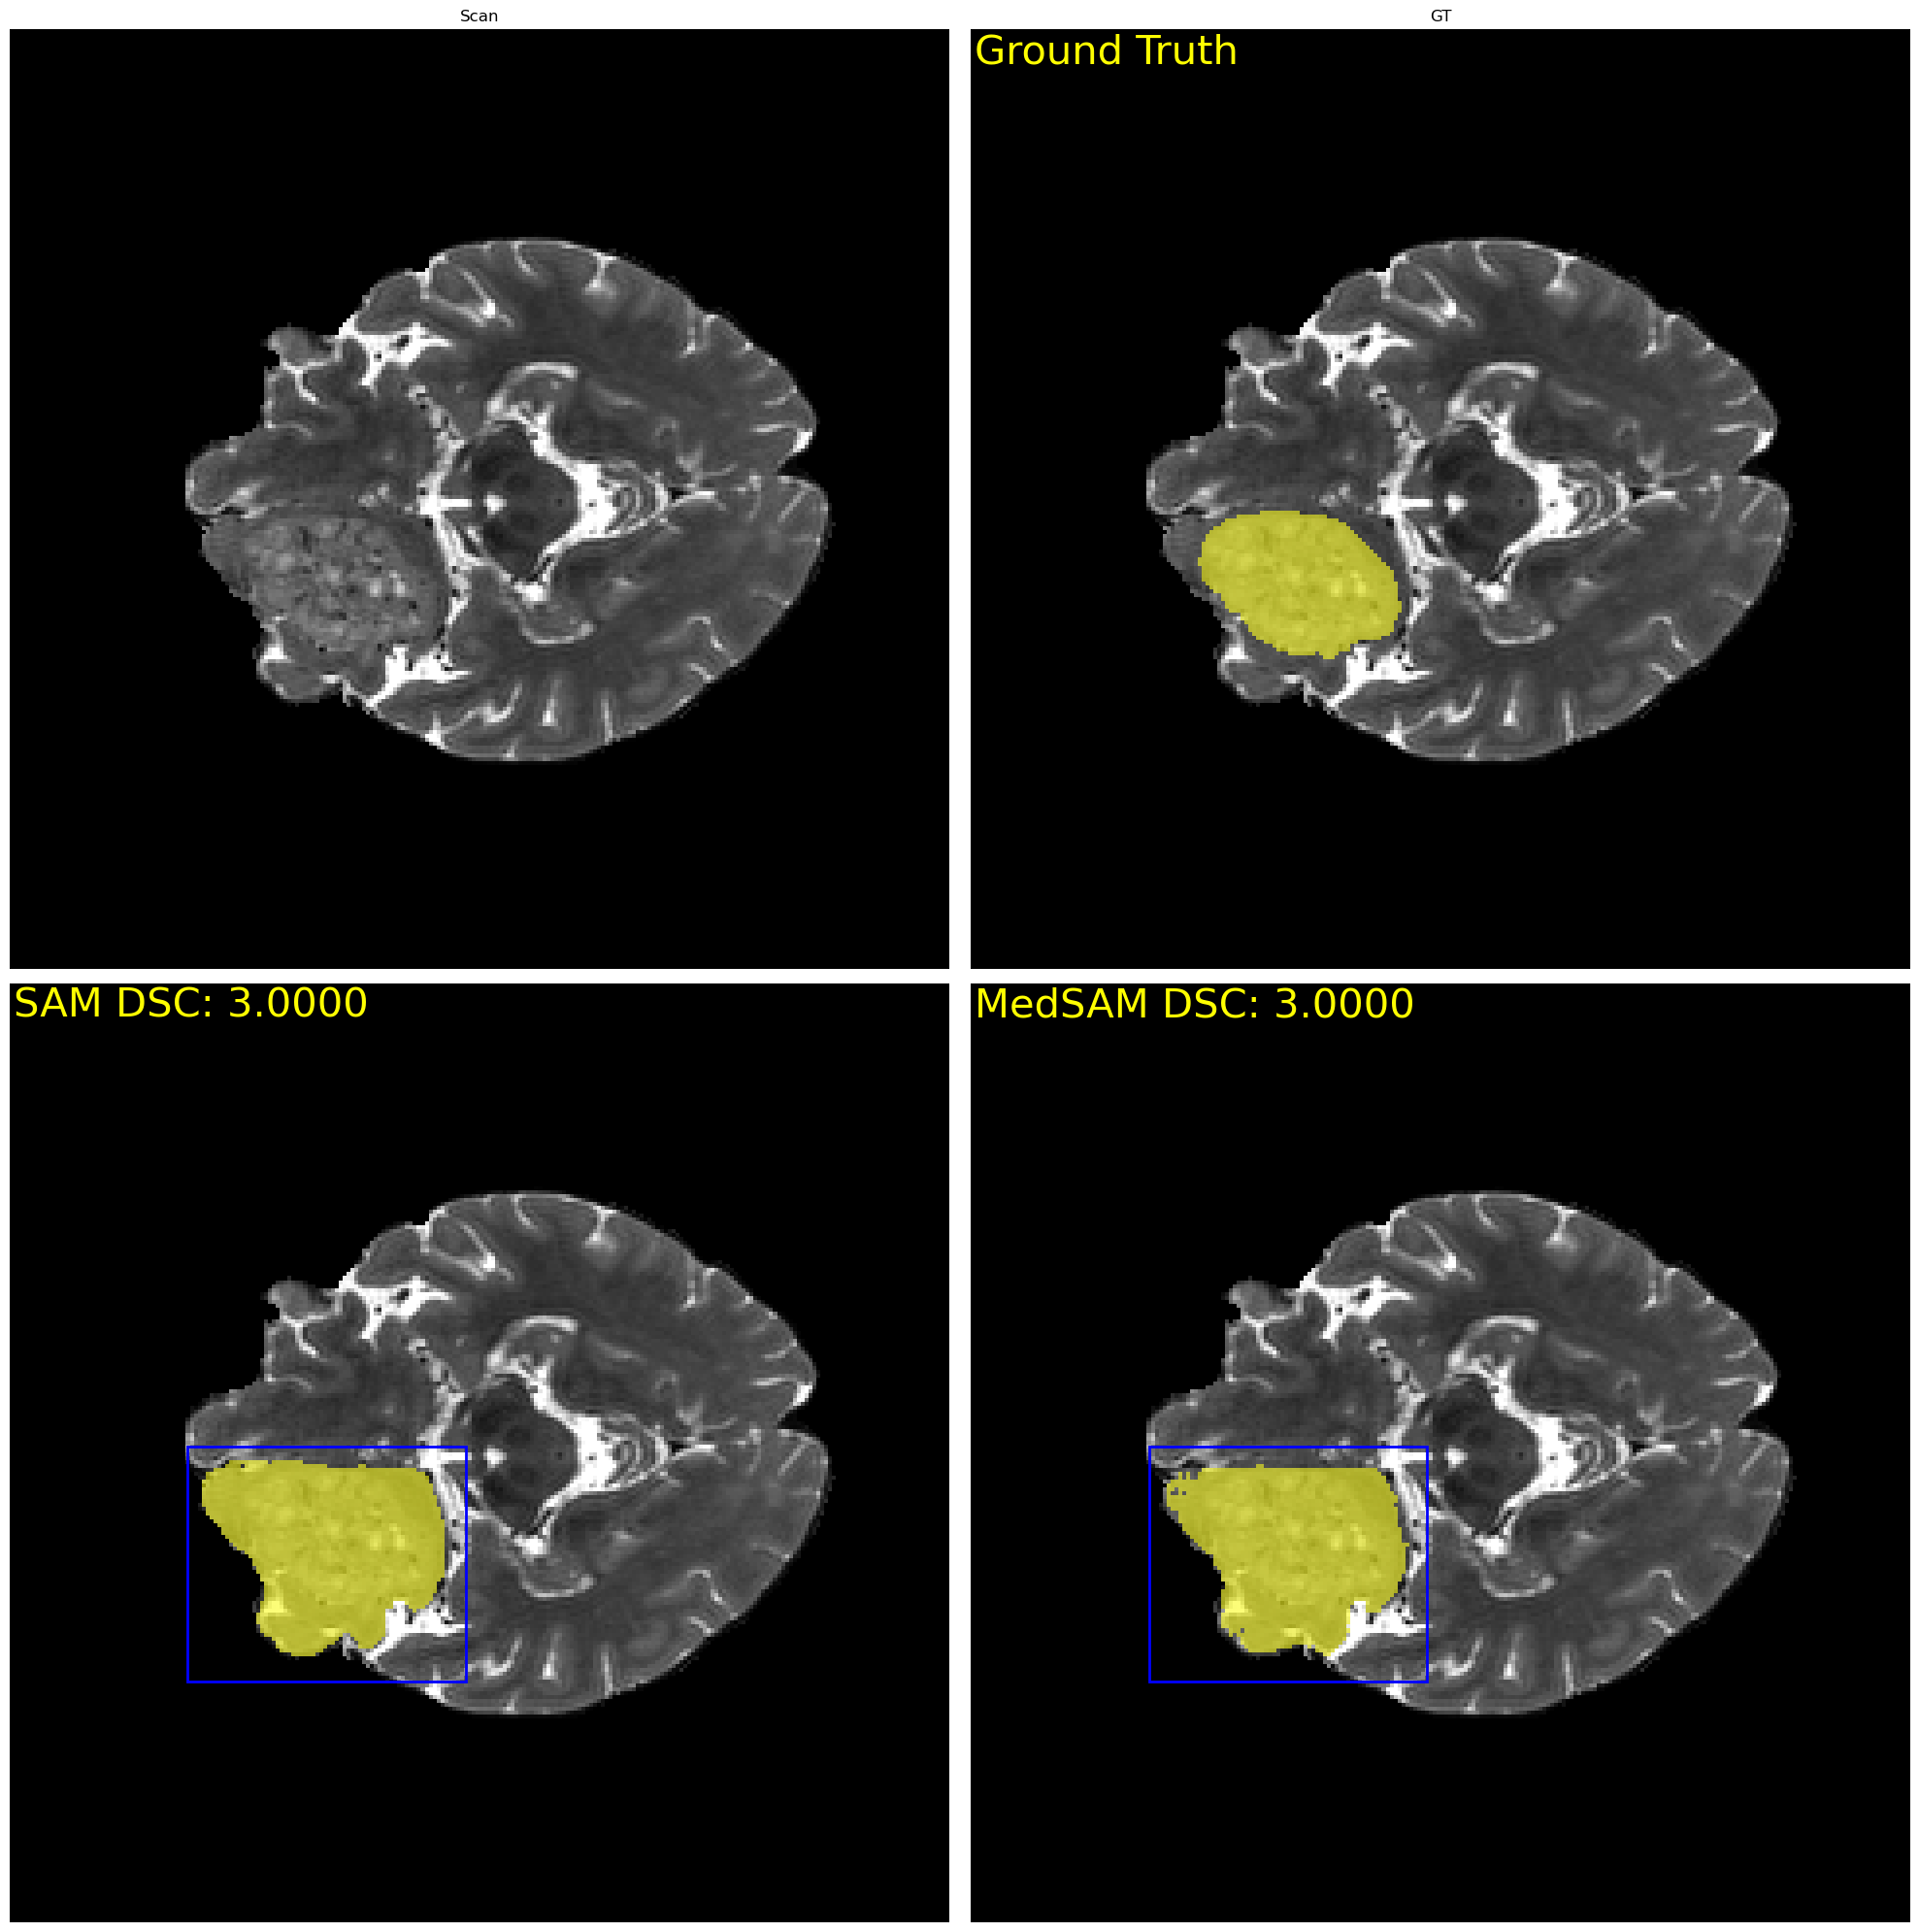

In [ ]:
def show_mask(mask, ax, random_color=False):
    if random_color:
        color = np.concatenate([np.random.random(3), np.array([0.6])], axis=0)
    else:
        color = np.array([251/255, 252/255, 30/255, 0.6])
    h, w = mask.shape[-2:]
    mask_image = mask.reshape(h, w, 1) * color.reshape(1, 1, -1)
    ax.imshow(mask_image)

def show_box(box, ax):
    x0, y0 = box[0], box[1]
    w, h = box[2] - box[0], box[3] - box[1]
    ax.add_patch(plt.Rectangle((x0, y0), w, h, edgecolor='blue', facecolor=(0,0,0,0), lw=2))

fig, axs = plt.subplots(2, 2, figsize=(20, 20))

# Scan original
axs[0, 0].imshow(scan_2d_pre, cmap='gray')
axs[0, 0].set_title('Scan')
axs[0, 0].axis('off')

# Scan + GT
axs[0, 1].imshow(scan_2d_pre)
show_mask(gt_2d > 0, axs[0, 1])        
axs[0, 1].axis('off')
axs[0, 1].set_title('GT')
axs[0, 1].text(0.5, 0.5, 'Ground Truth', fontsize=30, horizontalalignment='left', verticalalignment='top', color='yellow')

# SAM seg
axs[1, 0].imshow(scan_2d_pre)             
show_mask(sam_seg, axs[1, 0])     
show_box(gt_box, axs[1, 0])
axs[1, 0].text(0.5, 0.5, 'SAM DSC: {:.4f}'.format(sam_dsc), fontsize=30, horizontalalignment='left', verticalalignment='top', color='yellow')
axs[1, 0].axis('off')

# MedSAM seg
axs[1, 1].imshow(scan_2d_pre)            
show_mask(medsam_seg, axs[1, 1])     
show_box(gt_box, axs[1, 1])
axs[1, 1].text(0.5, 0.5, 'MedSAM DSC: {:.4f}'.format(medsam_dsc), fontsize=30, horizontalalignment='left', verticalalignment='top', color='yellow')
axs[1, 1].axis('off')

fig.tight_layout()



In [26]:
# Compréhension : 

# Les masques de tumeurs 
print("ground truth", np.unique(gt_2d))
print("predicted SAM", np.unique(sam_seg))
print("predicted mSAM", np.unique(medsam_seg))

'''
Pour le masque ground truth, il y a plusieurs valeurs qui sont je pense le type la région 

Annotations comprise the GD-enhancing tumor (ET — label 4), the peritumoral edematous/invaded tissue (ED — label 2), 
and the necrotic tumor core (NCR — label 1), as described both in the BraTS 2012-2013 TMI paper and in the latest 
BraTS summarizing paper. 

Mais nous on prédit juste la tumeur en général, donc on veut juste les valeurs > 0 

C'est pour ça que quand il les plogue il met gt_2d>0

'''
print("ground truth", np.unique(gt_2d>0))

ground truth [0. 1. 2. 4.]
predicted SAM [False  True]
predicted mSAM [0 1]
ground truth [False  True]


### Dice score

In [77]:
#Compute DICE score on both original and fine-tuned models
#from utils.SurfaceDice import compute_dice_coefficient
#from utils.SurfaceDice import compute_dice_coefficient

sam_dsc = compute_dice_coefficient(gt_2d>0, sam_seg>0)
medsam_dsc = compute_dice_coefficient(gt_2d>0, medsam_seg>0)
print('Original SAM DSC: {:.4f}'.format(sam_dsc), 'MedSAM DSC: {:.4f}'.format(medsam_dsc))

Original SAM DSC: 0.8996 MedSAM DSC: 0.8764
